# Storage-Aware Smoothing Metrics for Short-Term Estimated WEC Power

This notebook connects estimated wave energy converter (WEC) power variability, short-term forecasts, prediction intervals, and simple storage-aware smoothing metrics.

The goal is not to optimize BESS dispatch or produce final storage sizing. Instead, the notebook asks:

> Given a generic 250 kW WEC proxy, what storage burden is implied if the grid receives a smoother, forecast-informed, or uncertainty-aware version of the WEC power signal?

The analysis uses the 250 kW interpretation scale to express normalized estimated WEC-power results in approximate physical units. These values remain interpretation aids for the simplified WEC proxy, not final device or project ratings.


## 1. Scope, upstream workflow, and smoothing concept

This notebook builds on the previous workflow steps:

* [Literature map and research context](../outputs/pdf/00_literature_map.pdf)
* [Wave-resource data preparation](../outputs/pdf/01_wave_data_preparation.pdf)
* [Estimated WEC power from sea-state conditions](../outputs/pdf/02_wec_power_estimation.pdf)
* [Short-term point forecasting baselines](../outputs/pdf/03_forecasting_baselines.pdf)
* [Prediction intervals and uncertainty estimation](../outputs/pdf/04_prediction_intervals_uncertainty.pdf)
* Storage-aware smoothing metrics

The previous notebooks prepared the wave-resource data, estimated WEC power from sea-state conditions, evaluated short-term point forecasts, and calibrated empirical prediction intervals. This notebook uses those outputs to evaluate how different grid-export target definitions affect ramp-rate reduction and implied storage power, energy, throughput, and simple state-of-charge behavior.

The grid-export target is not prescribed as an arbitrary constant power level. Instead, it is derived from the estimated WEC power signal, point forecasts, or prediction interval bounds. This keeps the smoothing target tied to the available wave-energy resource. The analysis therefore asks how much storage power and energy would be required to transform a variable WEC power signal into a smoother grid-export profile.

The target represents a simplified export setpoint at the point of common coupling (PCC). It should not be interpreted as grid demand, market dispatch, or a validated grid-code requirement.


### Conceptual storage-smoothing balance

```text
Estimated WEC power
      p_wec
        │
        ▼
 ┌──────────────────┐
 │ Smoothing target │───▶ Grid export target
 │  selection rule  │        p_grid
 └──────────────────┘
        │
        ▼
Storage balancing power:
p_st = p_wec - p_grid

p_st > 0  → storage charges / absorbs surplus WEC power
p_st < 0  → storage discharges / supports grid delivery
```

In this notebook, storage is represented as an ideal balancing buffer connected at the grid-export interface. The WEC power is not assumed to pass entirely through storage. Instead, storage absorbs the positive mismatch when estimated WEC power exceeds the selected grid-export target and supplies the negative mismatch when estimated WEC power falls below that target.

The resulting storage power, cumulative energy swing, and state-of-charge trajectory are interpreted as smoothing-implied requirements, not as final BESS sizing results.


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown


pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True


# Paths are relative to the notebooks/ directory.
NOTEBOOK_ID = "notebook_05"

DATA_DIR = Path("../data")
OUTPUTS_DIR = Path("../outputs")

TABLES_DIR = OUTPUTS_DIR / "tables" / NOTEBOOK_ID
FIGURES_DIR = OUTPUTS_DIR / "figures" / NOTEBOOK_ID
NOTEBOOK_OUTPUT_DIR = OUTPUTS_DIR / NOTEBOOK_ID

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# Main input files generated by previous notebooks.
WEC_POWER_PATH = DATA_DIR / "processed" / "leixoes_wec_power_30min_estimated.parquet"
FORECAST_PATH = OUTPUTS_DIR / "notebook_03" / "forecast_predictions.parquet"
INTERVAL_PATH = OUTPUTS_DIR / "notebook_04" / "interval_predictions.parquet"


# Main interpretation scale used throughout this notebook.
RATED_POWER_KW = 250.0

# Main forecast / uncertainty setup used for the storage-aware scenarios.
SELECTED_MODEL = "Ridge"
SELECTED_INTERVAL_METHOD = "ConformalStyle_ModelHorizon"
MAIN_INTERVAL_LEVEL = 0.90

# The input data are on a 30-minute time step.
DT_MINUTES = 30
DT_HOURS = DT_MINUTES / 60

SMOOTHING_WINDOWS_MIN = [30, 60, 120, 240]

SMOOTHING_WINDOW_LABELS = {
    30: "30 min",
    60: "1 h",
    120: "2 h",
    240: "4 h",
}

wec_df = pd.read_parquet(WEC_POWER_PATH)
forecast_df = pd.read_parquet(FORECAST_PATH)
interval_df = pd.read_parquet(INTERVAL_PATH)


# WEC power time series from Notebook 02
wec_df = wec_df[
    [
        "time",
        "wec_power_kw_estimated",
        "wec_power_norm_estimated",
    ]
].copy()

wec_df["time"] = pd.to_datetime(wec_df["time"])

# Alias used in this notebook to make the 250 kW interpretation scale explicit.
wec_df["wec_power_kw_250"] = wec_df["wec_power_kw_estimated"]

wec_df = (
    wec_df
    .dropna(subset=["wec_power_kw_250", "wec_power_norm_estimated"])
    .sort_values("time")
    .reset_index(drop=True)
)


# Point forecasts from Notebook 03
forecast_df = forecast_df[
    [
        "sample_id",
        "origin_time",
        "target_time",
        "horizon_steps",
        "horizon_hours",
        "horizon_label",
        "fold_id",
        "split",
        "model",
        "y_true_norm",
        "y_pred_norm",
        "error_norm",
        "y_true_kw_250",
        "y_pred_kw_250",
        "error_kw_250",
    ]
].copy()

forecast_df["origin_time"] = pd.to_datetime(forecast_df["origin_time"])
forecast_df["target_time"] = pd.to_datetime(forecast_df["target_time"])


# Prediction intervals from Notebook 04
interval_df = interval_df[
    [
        "sample_id",
        "origin_time",
        "target_time",
        "horizon_steps",
        "horizon_hours",
        "horizon_label",
        "fold_id",
        "split",
        "model",
        "interval_method",
        "interval_level",
        "y_true_norm",
        "y_pred_norm",
        "lower_norm",
        "upper_norm",
        "interval_width_norm",
        "y_true_kw_250",
        "y_pred_kw_250",
        "lower_kw_250",
        "upper_kw_250",
        "interval_width_kw_250",
        "covered",
    ]
].copy()

interval_df["origin_time"] = pd.to_datetime(interval_df["origin_time"])
interval_df["target_time"] = pd.to_datetime(interval_df["target_time"])


print(f"Loaded WEC power time series: {wec_df.shape[0]:,} rows")
print(f"Loaded forecast predictions: {forecast_df.shape[0]:,} rows")
print(f"Loaded interval predictions: {interval_df.shape[0]:,} rows")

Loaded WEC power time series: 6,220 rows
Loaded forecast predictions: 102,396 rows
Loaded interval predictions: 615,072 rows


## 2. Smoothing scenarios and storage convention

The grid-export target is defined as a smoother version of the WEC power signal, not as an arbitrary constant power request. Depending on the scenario, the target is derived from the observed estimated WEC power, the selected point forecast, or the lower prediction bound.

The storage balance is defined as:

`p_st = p_wec - p_grid`

where:

* `p_wec` is the observed estimated WEC power.
* `p_grid` is the selected grid-export target.
* `p_st` is the storage balancing power.

The sign convention is:

* `p_st > 0`: WEC power exceeds the grid target, so storage charges.
* `p_st < 0`: WEC power is below the grid target, so storage discharges.

Here, “surplus” means surplus relative to the selected grid-export target. It does not mean surplus relative to grid demand. The target is a simplified export setpoint at the point of common coupling, while storage buffers the mismatch between available WEC power and that target.

The four smoothing scenarios are:

| Scenario                       | Grid-export target                        | Purpose                                                             |
| ------------------------------ | ----------------------------------------- | ------------------------------------------------------------------- |
| A. No smoothing                | `p_grid = p_wec`                          | Raw grid-export baseline with no storage action                     |
| B. Observed-power smoothing    | `p_grid = smooth(p_wec)`                  | Storage needed to deliver a smoother version of observed WEC power  |
| C. Forecast-informed smoothing | `p_grid = smooth(p_forecast)`             | Storage effect of using point forecasts to define the export target |
| D. Uncertainty-aware smoothing | `p_grid = smooth(lower prediction bound)` | Conservative target that accounts for forecast uncertainty          |


## 3. Raw variability and high-ramp baseline

Before defining smoothed grid-export targets, the raw estimated WEC power signal is summarized on the 250 kW interpretation scale.

The ramp between two consecutive 30-minute samples is calculated as:

`ramp(t) = p_wec(t) - p_wec(t-1)`

Large absolute ramps indicate periods where the WEC power changes rapidly. These periods are especially relevant for storage smoothing because they can create large short-term charge or discharge requirements.

There is no single universal threshold for defining a high-ramp event. In this notebook, high-ramp periods are defined as the top 5% of absolute target-to-target WEC power changes. This is a simple statistical definition used to highlight the most storage-relevant ramp tail, not a grid-code ramp-rate limit.


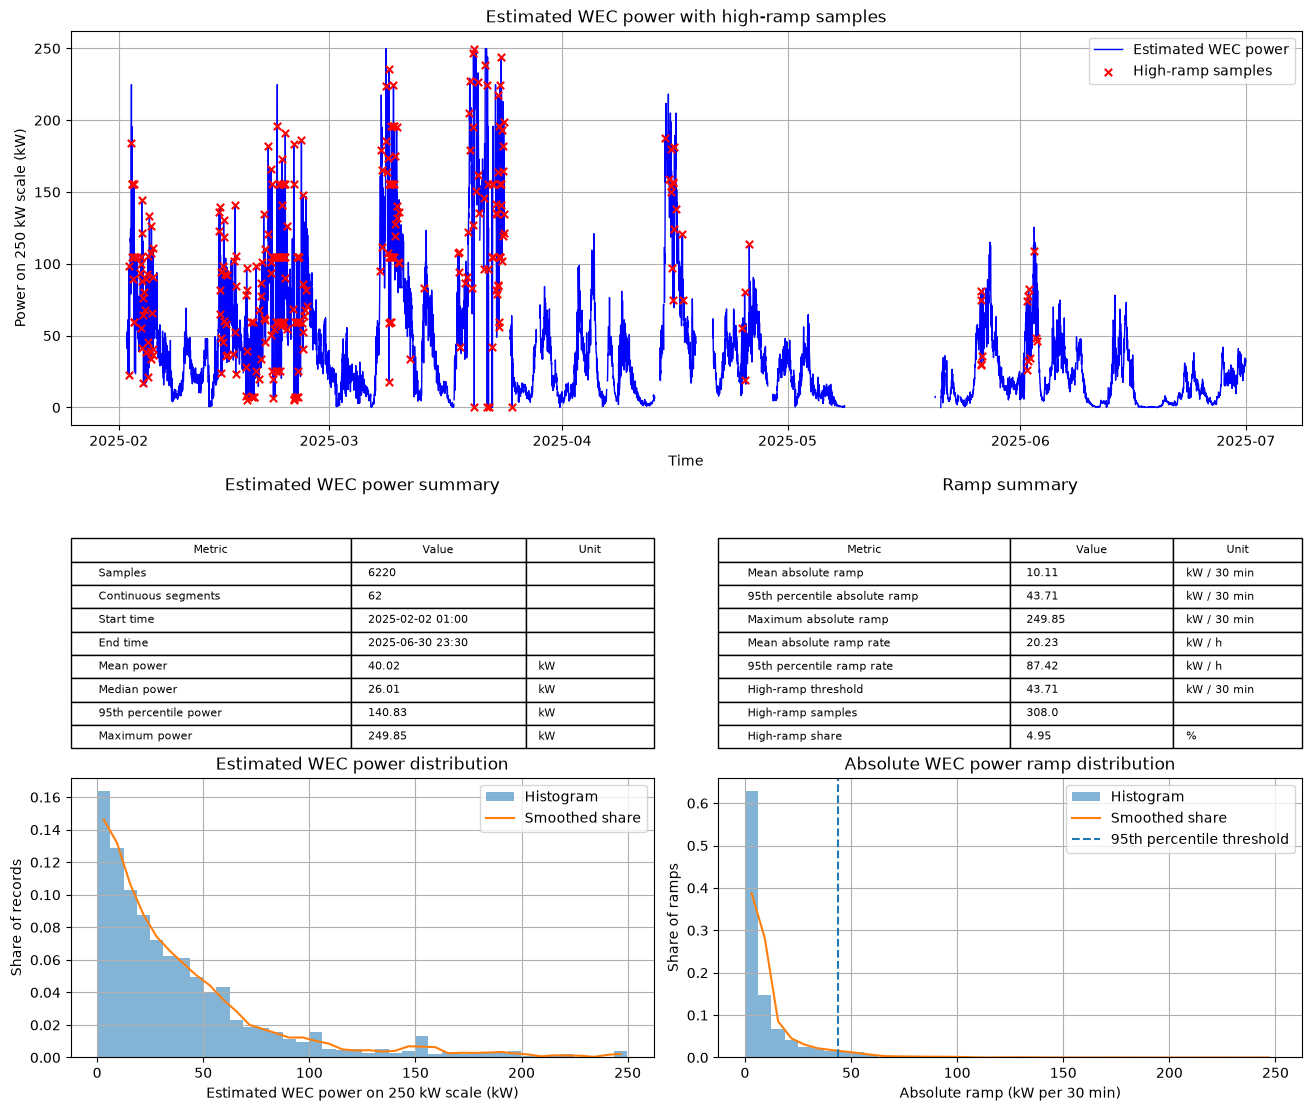

In [9]:
power_df = wec_df[
    [
        "time",
        "wec_power_kw_250",
        "wec_power_norm_estimated",
    ]
].copy()

power_df = power_df.rename(columns={"wec_power_kw_250": "p_wec_kw"})
power_df["time"] = pd.to_datetime(power_df["time"])

# Drop missing values and sort by time.
power_df = (
    power_df
    .dropna(subset=["p_wec_kw", "wec_power_norm_estimated"])
    .sort_values("time")
    .reset_index(drop=True)
)

# Detect gaps and define continuous segments.
power_df["time_diff_minutes"] = power_df["time"].diff().dt.total_seconds() / 60
power_df["is_new_segment"] = power_df["time_diff_minutes"].isna() | (power_df["time_diff_minutes"] > DT_MINUTES)
power_df["segment_id"] = power_df["is_new_segment"].cumsum()

# Compute ramps only within continuous segments.
power_df["ramp_kw_per_step"] = power_df["p_wec_kw"].diff()
power_df.loc[power_df["is_new_segment"], "ramp_kw_per_step"] = np.nan

power_df["abs_ramp_kw_per_step"] = power_df["ramp_kw_per_step"].abs()
power_df["ramp_kw_per_hour"] = power_df["ramp_kw_per_step"] / DT_HOURS
power_df["abs_ramp_kw_per_hour"] = power_df["ramp_kw_per_hour"].abs()

# High-ramp periods: top 5% of absolute ramps.
high_ramp_threshold_kw = power_df["abs_ramp_kw_per_step"].quantile(0.95)
power_df["is_high_ramp"] = power_df["abs_ramp_kw_per_step"] >= high_ramp_threshold_kw
power_df["is_high_ramp"] = power_df["is_high_ramp"].fillna(False)

power_summary = pd.DataFrame(
    [
        ["Samples", len(power_df), ""],
        ["Continuous segments", power_df["segment_id"].nunique(), ""],
        ["Start time", power_df["time"].min().strftime("%Y-%m-%d %H:%M"), ""],
        ["End time", power_df["time"].max().strftime("%Y-%m-%d %H:%M"), ""],
        ["Mean power", power_df["p_wec_kw"].mean(), "kW"],
        ["Median power", power_df["p_wec_kw"].median(), "kW"],
        ["95th percentile power", power_df["p_wec_kw"].quantile(0.95), "kW"],
        ["Maximum power", power_df["p_wec_kw"].max(), "kW"],
    ],
    columns=["Metric", "Value", "Unit"],
)

ramp_summary = pd.DataFrame(
    [
        ["Mean absolute ramp", power_df["abs_ramp_kw_per_step"].mean(), "kW / 30 min"],
        ["95th percentile absolute ramp", power_df["abs_ramp_kw_per_step"].quantile(0.95), "kW / 30 min"],
        ["Maximum absolute ramp", power_df["abs_ramp_kw_per_step"].max(), "kW / 30 min"],
        ["Mean absolute ramp rate", power_df["abs_ramp_kw_per_hour"].mean(), "kW / h"],
        ["95th percentile ramp rate", power_df["abs_ramp_kw_per_hour"].quantile(0.95), "kW / h"],
        ["High-ramp threshold", high_ramp_threshold_kw, "kW / 30 min"],
        ["High-ramp samples", int(power_df["is_high_ramp"].sum()), ""],
        ["High-ramp share", 100 * power_df["is_high_ramp"].mean(), "%"],
    ],
    columns=["Metric", "Value", "Unit"],
)

for summary_df in [power_summary, ramp_summary]:
    summary_df["Value"] = summary_df["Value"].apply(
        lambda x: round(x, 2) if isinstance(x, (int, float, np.floating)) else x
    )

power_summary.to_csv(TABLES_DIR / "raw_wec_power_summary.csv", index=False)
ramp_summary.to_csv(TABLES_DIR / "raw_ramp_summary.csv", index=False)

fig = plt.figure(figsize=(13, 11), constrained_layout=True)
gs = fig.add_gridspec(
    nrows=3,
    ncols=2,
    height_ratios=[2.4, 1.45, 1.7],
)

# ------------------------------------------------------------------
# Row 1: time series with high-ramp samples
# ------------------------------------------------------------------
ax_ts = fig.add_subplot(gs[0, :])

first_segment = True
for _, segment_df in power_df.groupby("segment_id"):
    ax_ts.plot(
        segment_df["time"],
        segment_df["p_wec_kw"],
        linewidth=1,
        color="blue",
        label="Estimated WEC power" if first_segment else None,
    )
    first_segment = False

high_ramp_points = power_df[power_df["is_high_ramp"]]

ax_ts.scatter(
    high_ramp_points["time"],
    high_ramp_points["p_wec_kw"],
    marker="x",
    s=28,
    color="red",
    label="High-ramp samples",
    zorder=3,
)

ax_ts.set_title("Estimated WEC power with high-ramp samples")
ax_ts.set_xlabel("Time")
ax_ts.set_ylabel("Power on 250 kW scale (kW)")
ax_ts.legend()

# ------------------------------------------------------------------
# Row 2: summary tables
# ------------------------------------------------------------------
ax_power_table = fig.add_subplot(gs[1, 0])
ax_ramp_table = fig.add_subplot(gs[1, 1])

ax_power_table.axis("off")
ax_ramp_table.axis("off")

power_table = ax_power_table.table(
    cellText=power_summary.values,
    colLabels=power_summary.columns,
    loc="center",
    cellLoc="left",
    colWidths=[0.48, 0.30, 0.22],
    bbox=[0.0, 0.0, 1.0, 0.88],
)

ramp_table = ax_ramp_table.table(
    cellText=ramp_summary.values,
    colLabels=ramp_summary.columns,
    loc="center",
    cellLoc="left",
    colWidths=[0.50, 0.28, 0.22],
    bbox=[0.0, 0.0, 1.0, 0.88],
)

for table in [power_table, ramp_table]:
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.25)

ax_power_table.set_title("Estimated WEC power summary", pad=14)
ax_ramp_table.set_title("Ramp summary", pad=14)

# ------------------------------------------------------------------
# Row 3: distributions
# ------------------------------------------------------------------
ax_power_hist = fig.add_subplot(gs[2, 0])
ax_ramp_hist = fig.add_subplot(gs[2, 1])

# Estimated power distribution
power_values = power_df["p_wec_kw"].dropna()
power_weights = np.ones(len(power_values)) / len(power_values)

power_shares, power_bins, _ = ax_power_hist.hist(
    power_values,
    bins=40,
    weights=power_weights,
    alpha=0.55,
    label="Histogram",
)

power_bin_centers = 0.5 * (power_bins[:-1] + power_bins[1:])
power_smooth = pd.Series(power_shares).rolling(
    window=3,
    center=True,
    min_periods=1,
).mean()

ax_power_hist.plot(
    power_bin_centers,
    power_smooth,
    linewidth=1.5,
    label="Smoothed share",
)

ax_power_hist.set_title("Estimated WEC power distribution")
ax_power_hist.set_xlabel("Estimated WEC power on 250 kW scale (kW)")
ax_power_hist.set_ylabel("Share of records")
ax_power_hist.legend()

# Ramp distribution
ramp_values = power_df["abs_ramp_kw_per_step"].dropna()
ramp_weights = np.ones(len(ramp_values)) / len(ramp_values)

ramp_shares, ramp_bins, _ = ax_ramp_hist.hist(
    ramp_values,
    bins=40,
    weights=ramp_weights,
    alpha=0.55,
    label="Histogram",
)

ramp_bin_centers = 0.5 * (ramp_bins[:-1] + ramp_bins[1:])
ramp_smooth = pd.Series(ramp_shares).rolling(
    window=3,
    center=True,
    min_periods=1,
).mean()

ax_ramp_hist.plot(
    ramp_bin_centers,
    ramp_smooth,
    linewidth=1.5,
    label="Smoothed share",
)

ax_ramp_hist.axvline(
    high_ramp_threshold_kw,
    linestyle="--",
    label="95th percentile threshold",
)

ax_ramp_hist.set_title("Absolute WEC power ramp distribution")
ax_ramp_hist.set_xlabel("Absolute ramp (kW per 30 min)")
ax_ramp_hist.set_ylabel("Share of ramps")
ax_ramp_hist.legend()

fig.savefig(
    FIGURES_DIR / "raw_variability_and_high_ramp_baseline.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

The estimated WEC power signal is strongly variable and right-skewed. Most records are concentrated at low-to-moderate power levels, while shorter energetic periods reach much higher output and occasionally approach the 250 kW interpretation scale.

The ramp distribution shows a similar pattern. Most 30-minute changes are small, but a smaller upper tail contains much larger target-to-target changes. These high-ramp periods are marked on the time-series plot and tend to cluster around energetic sea-state episodes, where storage smoothing would be most relevant.

Missing values and larger time gaps are not interpolated. Instead, the time series is split into continuous segments, and ramps are not computed across gaps. This avoids creating artificial ramp events from missing data.

The high-ramp threshold is defined as the 95th percentile of absolute 30-minute WEC power changes. This threshold is used as a transparent statistical marker for the most extreme ramp tail in this dataset. It is not a grid-code limit or a universal high-ramp definition.

## 4. Storage metric protocol applied to all scenarios

Storage metrics are computed by comparing the observed estimated WEC power with a selected grid-export target.

For each scenario, the storage balancing power is:

`p_st = p_wec - p_grid`

The cumulative storage energy trajectory is estimated by integrating storage power over time:

`E_st(t) = cumulative sum of p_st × Δt`

The required usable storage energy is calculated as the peak-to-peak swing of the cumulative energy trajectory within each continuous segment. This gives the energy capacity required to follow the selected grid-export target under an ideal lossless-storage assumption.

The same metric protocol is applied to all scenarios:

* no smoothing
* observed-power smoothing
* forecast-informed smoothing
* uncertainty-aware smoothing

For fair comparison, the scenario metrics are evaluated on aligned test-set rows from the forecasting and prediction-interval outputs. This keeps the observed WEC power, selected point forecasts, and prediction intervals on the same target timestamps, forecast horizons, and rolling-origin folds.
